In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. LOAD DATA
# ==============================

df = pd.read_csv("/content/college_student_placement_dataset.csv")
print(df.head())

  College_ID  Prev_Sem_Result  CGPA  Academic_Performance  \
0    CLG0030             6.61  6.28                     8   
1    CLG0061             5.52  5.37                     8   
2    CLG0036             5.36  5.83                     9   
3    CLG0055             5.47  5.75                     6   
4    CLG0004             7.91  7.69                     7   

  Internship_Experience  Extra_Curricular_Score  Communication_Skills  \
0                    No                       8                     8   
1                    No                       7                     8   
2                    No                       3                     1   
3                   Yes                       1                     6   
4                    No                       8                    10   

   Projects_Completed Placement  
0                   4        No  
1                   0        No  
2                   1        No  
3                   1        No  
4                   2   

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   Prev_Sem_Result         10000 non-null  float64
 2   CGPA                    10000 non-null  float64
 3   Academic_Performance    10000 non-null  int64  
 4   Internship_Experience   10000 non-null  object 
 5   Extra_Curricular_Score  10000 non-null  int64  
 6   Communication_Skills    10000 non-null  int64  
 7   Projects_Completed      10000 non-null  int64  
 8   Placement               10000 non-null  object 
dtypes: float64(2), int64(4), object(3)
memory usage: 703.3+ KB


In [11]:
df.describe()

,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


In [12]:
#  Clean column names
df.columns = df.columns.str.strip().str.lower()

In [13]:
# Print columns to verify
print("Columns in dataset:", df.columns)

Columns in dataset: Index(['college_id', 'prev_sem_result', 'cgpa', 'academic_performance',
       'internship_experience', 'extra_curricular_score',
       'communication_skills', 'projects_completed', 'placement'],
      dtype='object')


In [14]:
# Try to find placement/status column automatically
possible_cols = ['status', 'placement_status', 'placed', 'placement']

target_col = None
for col in possible_cols:
    if col in df.columns:
        target_col = col
        break

In [15]:
#  If not found, raise error
if target_col is None:
    raise Exception("❌ No placement/status column found. Check column names!")

print(f"✅ Using column: {target_col}")


✅ Using column: placement


In [16]:
# Value counts (important for ML understanding)
print("\nPlacement Count:")
print(df[target_col].value_counts())


Placement Count:
placement
No     8341
Yes    1659
Name: count, dtype: int64


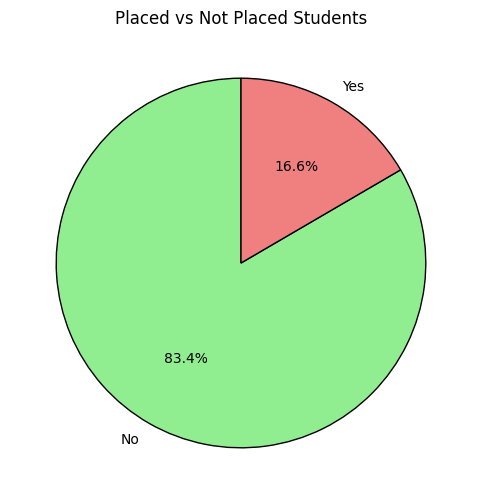

In [17]:
# Plot pie chart
plt.figure(figsize=(6,6))

df[target_col].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['lightgreen','lightcoral'],
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)

plt.title("Placed vs Not Placed Students")
plt.ylabel("")  # remove ylabel
plt.show()

In [ ]:
# ==============================
# 2. Data cleaning and preprocessing
# ==============================

In [22]:
# Drop unnecessary data
for col in df.columns:
    if df[col].nunique() == 1:
        df.drop(col, axis=1, inplace=True)

In [23]:
# checking missing values
df.isnull().sum()

,0
college_id,0
prev_sem_result,0
cgpa,0
academic_performance,0
internship_experience,0
extra_curricular_score,0
communication_skills,0
projects_completed,0
placement,0


In [32]:
print(df.columns)
print(df.head())

Index(['college_id', 'prev_sem_result', 'cgpa', 'academic_performance',
       'internship_experience', 'extra_curricular_score',
       'communication_skills', 'projects_completed', 'placement'],
      dtype='object')
  college_id  prev_sem_result  cgpa  academic_performance  \
0    CLG0030             6.61  6.28                     8   
1    CLG0061             5.52  5.37                     8   
2    CLG0036             5.36  5.83                     9   
3    CLG0055             5.47  5.75                     6   
4    CLG0004             7.91  7.69                     7   

  internship_experience  extra_curricular_score  communication_skills  \
0                    No                       8                     8   
1                    No                       7                     8   
2                    No                       3                     1   
3                   Yes                       1                     6   
4                    No                       8  

In [ ]:
# ==============================
# 3. ENCODE CATEGORICAL DATA
# ==============================

In [34]:
# Encode categorical columns (Applying Preprocessing)
from sklearn.preprocessing import LabelEncoder,StandardScaler
le = LabelEncoder()

cat_cols = ['college_id','internship_experience','placement']

for col in cat_cols:
    if col in df.columns:   # avoid KeyError
        le = LabelEncoder() # new encoder per column
        df[col] = le.fit_transform(df[col])

In [35]:
# Scale Numerical columns
scaler = StandardScaler()
num_cols = ['prev_sem_result','cgpa','academic_performance','extra_curricular_score','communication_skills','projects_completed']
df[num_cols]=scaler.fit_transform(df[num_cols])

In [36]:
# Saved preprocessed dataframe for model training
df.to_csv("/content/preprocessed_dataset.csv",index=False)

In [ ]:
# ==============================
# 4. model Training and Evaluation
# ==============================

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

# Load preprocessed data
df = pd.read_csv("/content/preprocessed_dataset.csv")

In [41]:
# split features and taget
X =df.drop('placement',axis=1)
Y =df['placement']

In [44]:
#Train test split
X_train,X_test , Y_train,Y_test = train_test_split(X,Y,test_size= 0.2,random_state=42)

# Model Training
model =RandomForestClassifier()
model.fit(X_train,Y_train)

# Prediction
y_pred = model.predict(X_test)

#Evaluation
print("Accuracy:",accuracy_score(Y_test,y_pred))

print("confusion matrix:\n",confusion_matrix(Y_test,y_pred))

print("classification Report:\n",classification_report(Y_test,y_pred))

Accuracy: 0.918
confusion matrix:
 [[1671    3]
 [ 161  165]]
classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95      1674
           1       0.98      0.51      0.67       326

    accuracy                           0.92      2000
   macro avg       0.95      0.75      0.81      2000
weighted avg       0.92      0.92      0.91      2000

